# Analytical Power Analysis

## Setup

In [ ]:
#| label: setup
#| include: false

# For CFA population models
source(here::here("Scripts", "DataAppendixScripts", "models.R"))

# For DRY (Don't repeat yourself) parameters
source(here::here("Scripts", "DataAppendixScripts", "helpers.R"))

## Computing model degrees of freedom

Before any analytical power calculation can be performed, the model degrees of freedom ($df$) must be established. This quantity is the difference between the number of unique variances and covariances in the observed data and the number of freely estimated parameters. It enters the non-central $\chi^2$ distribution directly and is therefore required for both the a priori and the power-curve analyses that follow \[@jak2021; @moshagen2024\].

In [ ]:
#| label: compute-df

# Compute df for standardized latent variables
# 24 observed variables: p*(p+1)/2 = 300 non-redundant sample moments
# analyzemodel: 24 loadings + 6 factor correlations + 1 residual covariance (Q3~~Q4) + 24 residual variances = 55 free parameters
# Model degrees of freedom: df = 300 - 55 = 245
df_model <- semPower.getDf(analyzemodel)-4
# Minus 4 because the 4 residual variances are fixed to 1 in analyzemodel, 
# and in the foward analysis we use std.lv = TRUE (standardized latent variables). 

cat("Model degrees of freedom:", df_model, "\n")

Model degrees of freedom: 245 

## A priori power analysis: Determine N

### Model-free approach (RMSEA-based)

The model-free strategy determines the required sample size from four ingredients — the target RMSEA, the significance level, the desired power, and the model degrees of freedom — without requiring an explicitly specified population model \[@maccallum1996; @jak2021\]. Because RMSEA expresses misfit per degree of freedom, it translates directly into the noncentrality parameter $\lambda = (N-1)\,df\,\text{RMSEA}^2$, which locates the alternative $\chi^2$ distribution relative to the null \[@maccallum1996\].

The output below returns the minimum $N$ needed to detect $\text{RMSEA} = 0.05$ under the chosen $\alpha$ and power, together with equivalent representations of the same effect in terms of $F_0$, $Mc$, $GFI$, and $AGFI$ \[@moshagen2024\].

In [ ]:
#| label: apriori-rmsea-raw

# Analytical a priori power analysis for the global chi-square test.
# The goal is to determine the minimum N required to detect
# a population misfit corresponding to RMSEA = 0.05.

ap_rmsea <- semPower::semPower.aPriori(
  effect         = 0.05,      # RMSEA under H1
  effect.measure = "RMSEA",   # effect is expressed as RMSEA
  alpha          = ALPHA,     # Type I error rate defined in helpers.R
  power          = POWER,     # desired statistical power defined in helpers.R
  df             = df_model,  # model degrees of freedom calculated in "compute-df" chunk
  p              = P          # number of observed indicators defined in helpers.R
)

> **Standard software output**
>
> Calling `summary()` directly prints the full terminal summary table alongside the central vs. non-central chi-square distribution plot. In an interactive R session, executing `summary(ap_rmsea)` is sufficient to inspect analytical results immediately. For formal manuscript presentation and publication rendering, the composite output is decoupled into an academic table and an isolated distribution figure.

In [ ]:
#| label: tbl-apriori-rmsea
#| tbl-cap: "Analytical a priori power parameters for RMSEA = 0.05"

# Formatted table extracting analytical power metrics for clean manuscript embedding
table_sempower(ap_rmsea) # See function definition in helpers.R

  --------------------------------------------------------------------------
  Metric                                           Symbol              Value
  --------------------------------------- ------------------------ ---------
  Population discrepancy                           $F_0$               0.613

  Root mean square error of approximation      $\text{RMSEA}$          0.050

  McDonald centrality index                         $Mc$               0.736

  Goodness-of-fit index                         $\text{GFI}$           0.951

  Adjusted goodness-of-fit index               $\text{AGFI}$           0.941

  Degrees of freedom                                $df$                 245

  Required sample size                              $N$                  100

  Critical chi-square                      $\chi^2_{\text{crit}}$    282.511

  Noncentrality parameter                        $\lambda$            60.638

  Significance level (alpha)                      $\alpha$             0.050

  Type II error rate (beta)                       $\beta$             0.1984

  Statistical power                             $1 - \beta$           0.8016
  --------------------------------------------------------------------------


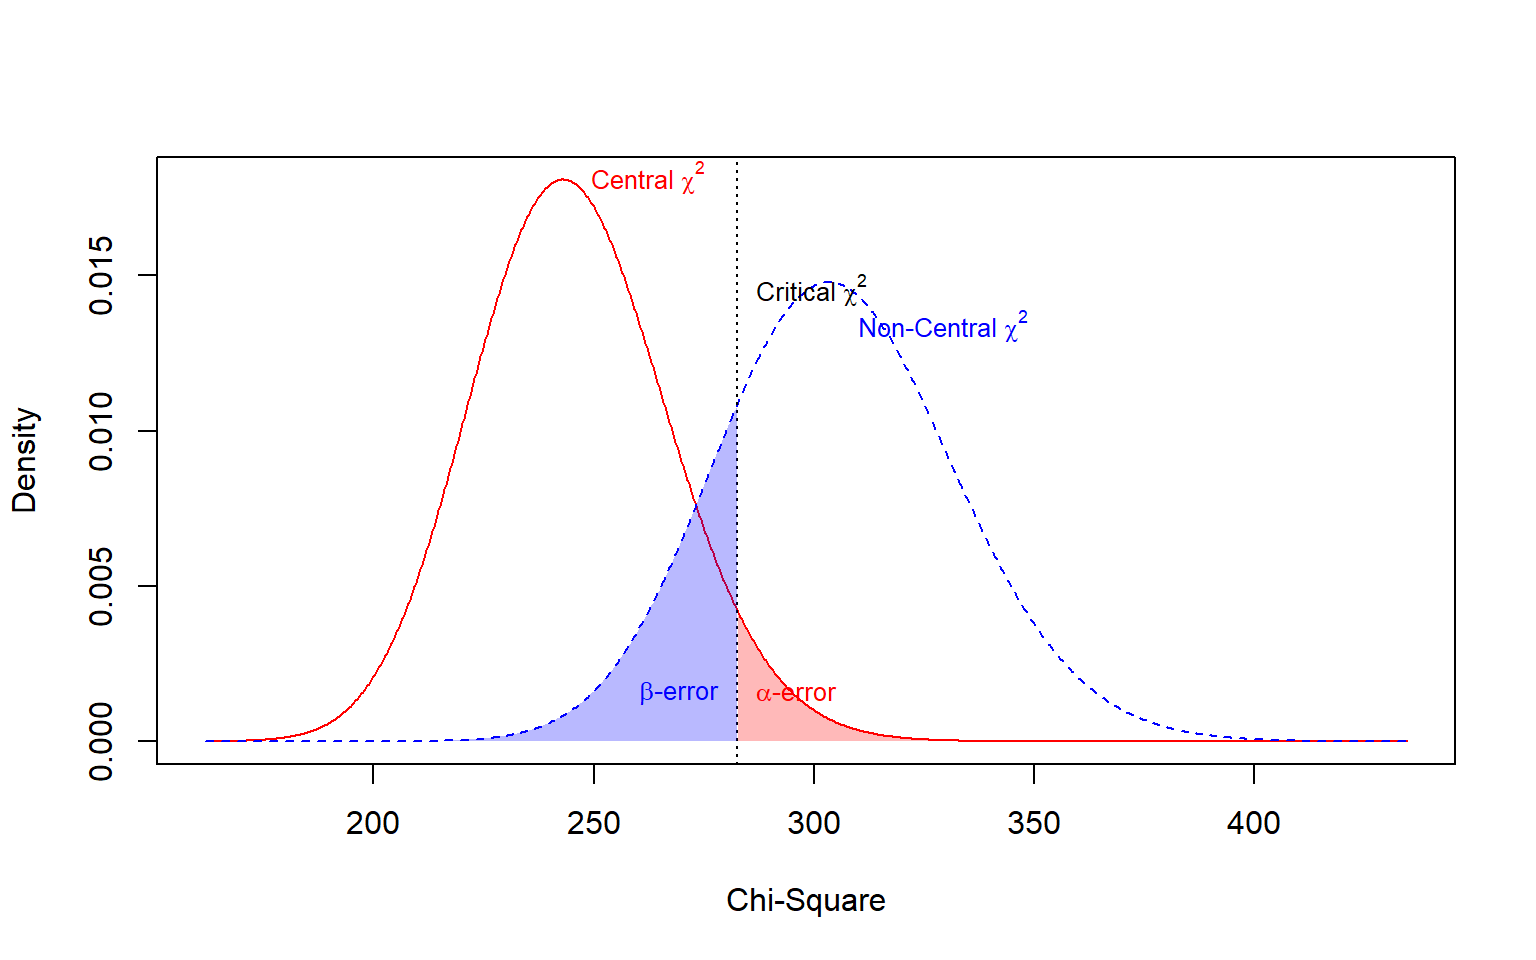

In [ ]:
#| label: fig-apriori-rmsea
#| fig-cap: "A priori power analysis for exact fit with RMSEA-based effect size"
#| fig-width: 8
#| fig-height: 5

# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ap_rmsea) # See function definition in helpers.R

### Model-based approach (with lavaan syntax)

When the substantive hypothesis is grounded in an explicit population model, the effect no longer needs to be set by convention: it is implied by the discrepancy between the population covariance structure and the restrictions imposed by the analysis model \[@wang2023; @feng2023\]. This makes the sample size estimate more directly tied to the CFA under study, at the cost of requiring a fully specified population model as input \[@buchberger2024; @moshagen2024\].

Here, `semPower.powerLav()` fits the analysis model (`analyzemodel`) to the covariance matrix implied by the misspecified population model (`h1model`) and translates the resulting discrepancy into $F_0$ and then into $\lambda = (N-1)F_0$. Because `modelH1` is not specified, the comparison is against the saturated model, evaluating overall model misfit ($df = 245$).

In [ ]:
#| label: apriori-popmodel-raw

# A priori power analysis:
# computes the minimum N needed to detect the omission of the three
# cross-loadings in analyzemodel when data arise from h1model.

ap_popmodel <- semPower::semPower.powerLav(
  type       = "a-priori", # Type of power analysis
  alpha      = ALPHA,      # Type I error rate defined in helpers.R
  power      = POWER,      # desired statistical power defined in helpers.R
  modelPop   = h1model,    # population model defined in "models.R"
  modelH0    = analyzemodel, # analysis model defined in "models.R"
  lavOptions = list(std.lv = TRUE) # Standardize latent variables
)

> **Standard software output**
>
> Calling `summary()` directly prints the full terminal summary table alongside the central vs. non-central chi-square distribution plot. In an interactive R session, executing `summary(ap_popmodel)` is sufficient to inspect analytical results immediately. For formal manuscript presentation and publication rendering, the composite output is decoupled into an academic table and an isolated distribution figure.

In [ ]:
#| label: tbl-apriori-popmodel
#| tbl-cap: "Analytical a priori power parameters for model-based approach (h1model vs analyzemodel)"

# Formatted table extracting model-based power metrics for clean manuscript embedding
table_sempower(ap_popmodel) # See function definition in helpers.R

  --------------------------------------------------------------------------
  Metric                                           Symbol              Value
  --------------------------------------- ------------------------ ---------
  Population discrepancy                           $F_0$               0.579

  Root mean square error of approximation      $\text{RMSEA}$          0.049

  McDonald centrality index                         $Mc$               0.749

  Standardized root mean square residual       $\text{SRMR}$           0.067

  Comparative fit index                         $\text{CFI}$           0.960

  Degrees of freedom                                $df$                 245

  Required sample size                              $N$                  106

  Critical chi-square                      $\chi^2_{\text{crit}}$    282.511

  Noncentrality parameter                        $\lambda$            60.793

  Significance level (alpha)                      $\alpha$             0.050

  Type II error rate (beta)                       $\beta$             0.1968

  Statistical power                             $1 - \beta$           0.8032
  --------------------------------------------------------------------------


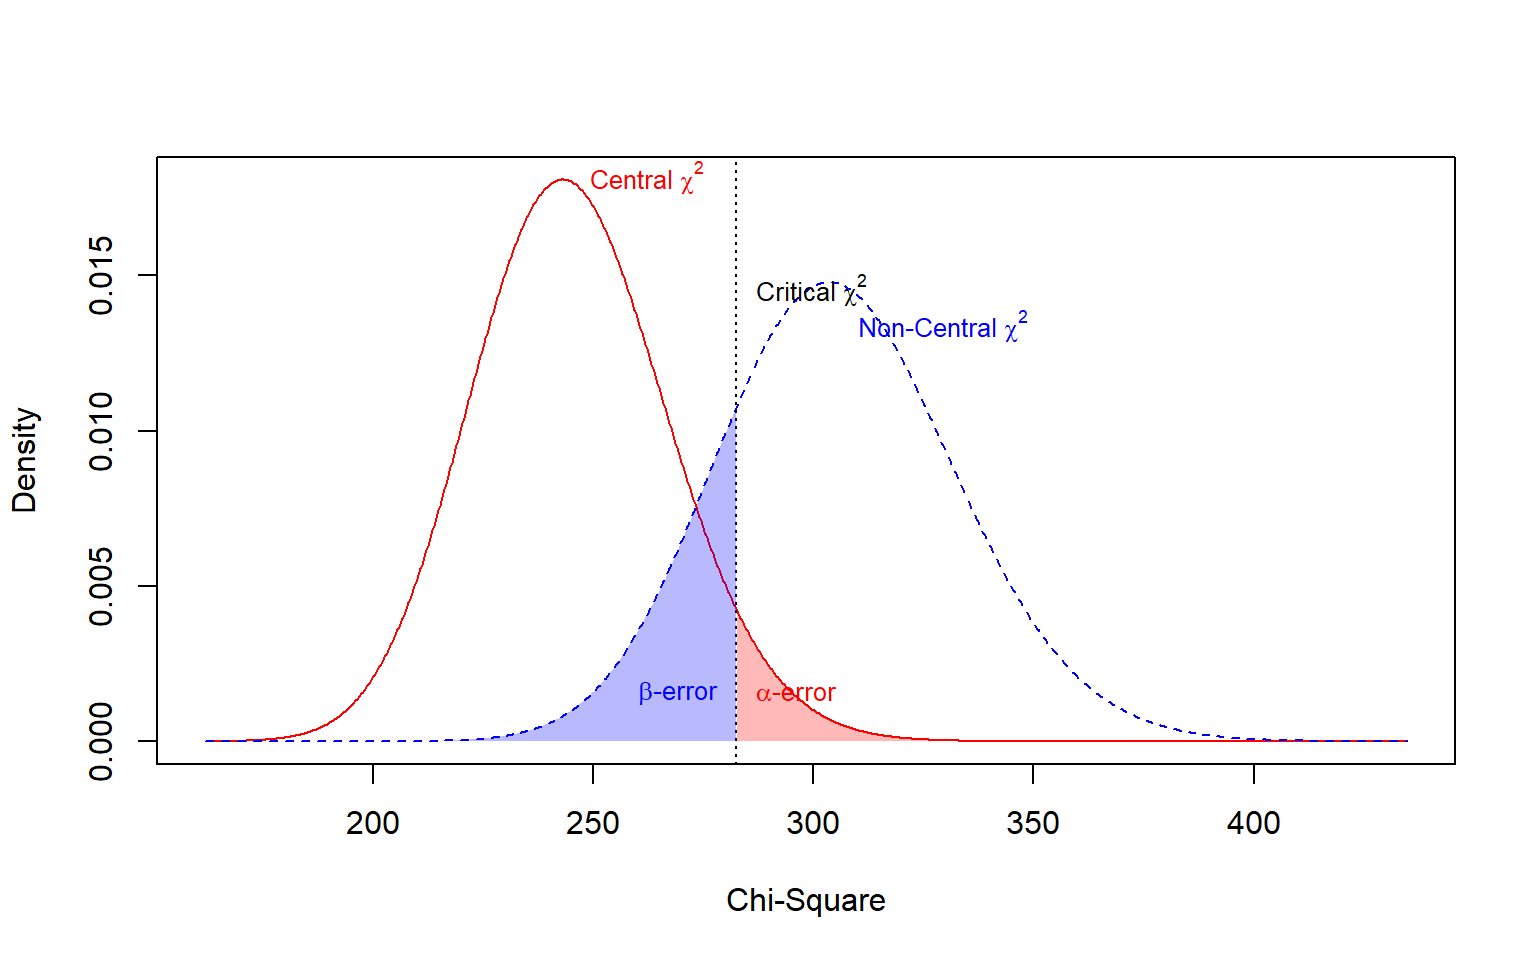

In [ ]:
#| label: fig-apriori-popmodel
#| fig-cap: "A priori power analysis Model-based approach (h1model vs analyzemodel)"
#| fig-width: 8
#| fig-height: 5

# Isolated chi-square distribution plot for clean manuscript embedding
plot_sempower(ap_popmodel) # See function definition in helpers.R

## Power curves

Power curves shift the discussion from a single required-$N$ result to a continuous view of how detection probability changes as sample size grows. They are useful for communicating the design in a way that makes trade-offs between $N$, power, and tolerated misspecification immediately visible \[@wang2023; @moshagen2024\].

### Model-free approach

The curve below is analytical and model-free: power is a function of RMSEA, $df$, and $\alpha$ only. It answers the planning question of how many observations are needed to detect a fixed degree of global misspecification across a range of possible $N$ values \[@jak2021; @jobst2023\].

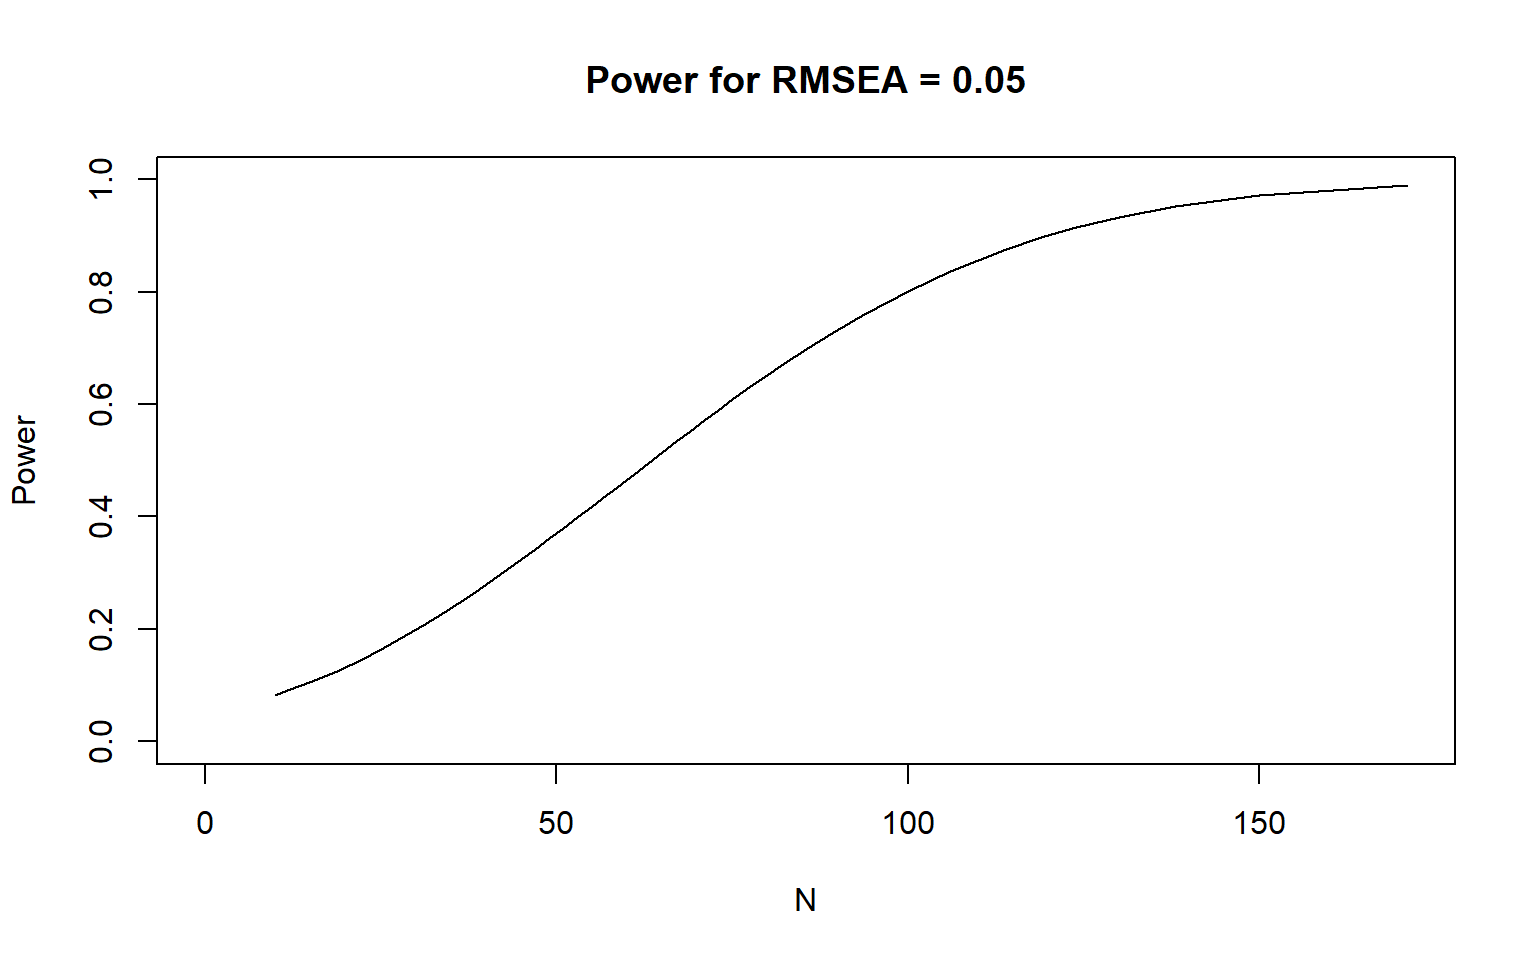

In [ ]:
#| label: fig-power-rmsea
#| fig-cap: "Power as a function of sample size for RMSEA = 0.05"
#| fig-width: 8
#| fig-height: 5

# Plots statistical power against sample size N.
semPower::semPower.powerPlot.byN(
  effect         = 0.05,      # Target misfit in RMSEA units.
  effect.measure = "RMSEA",   # Type of effect measure
  alpha          = ALPHA,     # Type I error rate defined in helpers.R
  df             = df_model,  # Model degrees of freedom calculated in "compute-df" chunk
  power.min      = 0.05,      # Min. Power define the y-axis range
  power.max      = 0.99       # Max. Power define the y-axis range
)

### Model-based approach

This curve traces the same power function for the model-based effect stored in `ap_popmodel`. Because the effect here is derived from the population covariance structure, the curve reflects the specific degree of misspecification implied by the substantive CFA, rather than a generic RMSEA threshold \[@feng2023; @buchberger2024\]. The sample-size region in which the curve crosses the target power level is the practical read-off from this figure \[@moshagen2024\].

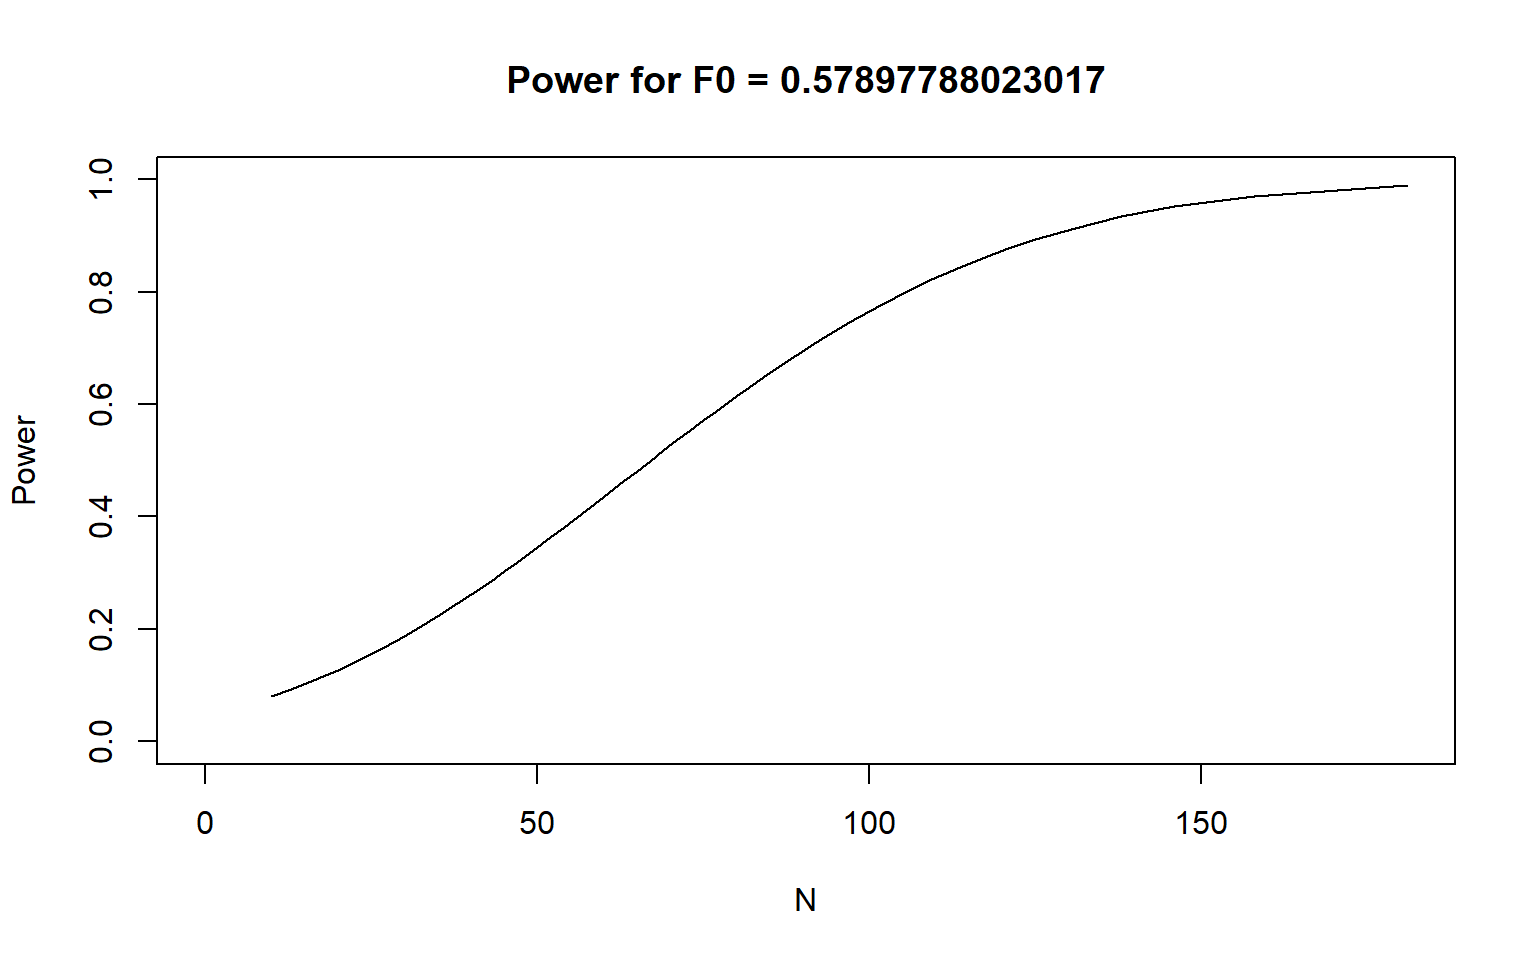

In [ ]:
#| label: fig-power-popmodel
#| fig-cap: "Power as a function of sample size for the population model (popModel)"
#| fig-width: 8
#| fig-height: 5

# Plots the power curve based on the previously computed object `ap_popmodel`.
# x-axis: sample size (N).
# y-axis: statistical power.

semPower.powerPlot(ap_popmodel)

## Summary table

The table below brings the two analytical solutions together, allowing a direct comparison of their sample size requirements under the same $\alpha$ and power targets. The difference between the two estimates reflects a general principle: once the effect is derived from a specific population model rather than from a generic RMSEA convention, the resulting $N$ becomes more substantively grounded and, in this case, more conservative \[@wang2023; @feng2023\].

In [ ]:
#| label: tbl-analytical-summary
#| tbl-cap: "Summary of analytical power analysis results"

# Helper to safely extract a single numeric value from each result object
safe_num <- function(x) if (length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

# Create a summary table of the analytical power analysis results
analytical_summary <- data.frame(
    Method = c(
        "Model-free a priori (RMSEA = .05)",
        "Model-based global fit (h1model vs. saturated)"
    ),
    `N Required` = c(
        safe_num(ap_rmsea$requiredN),
        safe_num(ap_popmodel$requiredN)
    ),
    `Power` = c(
        round(safe_num(ap_rmsea$impliedPower), 4),
        round(safe_num(ap_popmodel$impliedPower), 4)
    ),
    `Implied RMSEA` = c(
        round(safe_num(ap_rmsea$rmsea), 4),
        round(safe_num(ap_popmodel$rmsea), 4)
    ),
    df = c(
        safe_num(ap_rmsea$df),
        safe_num(ap_popmodel$df)
    ),
    check.names = FALSE
)

# Render the summary table with simple column alignment
knitr::kable(analytical_summary, align = "lcccc")

  -----------------------------------------------------------------------------
  Method                                 N Required  Power     Implied     df
                                                                RMSEA     
  -------------------------------------- ---------- -------- ------------ -----
  Model-free a priori (RMSEA = .05)         100      0.8016     0.0500     245

  Model-based global fit (h1model           106      0.8032     0.0486     245
  vs. saturated)                                                          
  -----------------------------------------------------------------------------
